### In the following notebook CPT data (GEF form) will be processed to classify in Robertson 1990 classification

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl
from pathlib import Path
from matplotlib.patches import Ellipse
from PIL import Image
from lengkeek_chart import create_lengkeek_background_axis

In [2]:
# loading the CPT data and preparing it for the classification

# "C:\Users\Arend-Jan\CPT measurements\Campus-Zuid\Pre-boren\S1022749_CPTU1-2.gef"

# "C:\Users\Arend-Jan\CPT measurements\Campus-Zuid\Pre-boren\S1022749_CPTU1-4.gef"

# Path to your file (keep it as .gef!)
path_2m = r"C:\AA_Thesis\CPT_Measurements\Campus-Zuid\Pre-boren\S1022749_CPTU1-2.gef"
path_4m = r"C:\AA_Thesis\CPT_Measurements\Campus-Zuid\Pre-boren\S1022749_CPTU1-4.gef"

# 1. Find where the data starts and change all values less than zero to NaN
def load_cpt(path, z_target=-30.0):
    columns = [
        'depth', 'qc', 'fs', 'Rf', 'u2',
        'Slope X', 'Slope Y', 'corrected depth', 'time'
    ]

    a_value = None
    z_start_NAP = None

    with open(path, 'r') as f:
        lines = f.readlines()
        skip_count = 0

        for i, line in enumerate(lines):

            # Area ratio for qt correction
            if '#MEASUREMENTVAR= 3' in line:
                try:
                    a_value = float(line.split(',')[1].strip())
                except (ValueError, IndexError):
                    print(f"Warning: Could not parse area ratio in {path}. Using default.")
                    a_value = 0.8

            # Starting elevation in NAP
            if '#ZID=' in line:
                try:
                    # Example: #ZID= 31000, -1.37, 0.03
                    z_start_NAP = float(line.split(',')[1].strip())
                except (ValueError, IndexError):
                    raise ValueError(f"Could not parse #ZID elevation in {path}")

            # End of header
            if '#EOH=' in line:
                skip_count = i + 1
                break

    if a_value is None:
        raise ValueError(f"Could not find area ratio '#MEASUREMENTVAR= 3' in {path}")

    if z_start_NAP is None:
        raise ValueError(f"Could not find starting elevation '#ZID=' in {path}")

    df = pd.read_csv(path, skiprows=skip_count, sep=r'\s+', header=None)
    df.columns = columns

    # Replace invalid GEF values
    df[df < -200] = np.nan

    # Corrected cone resistance
    df['qt'] = df['qc'] + (df['u2'] * (1 - a_value))

    # Elevation relative to NAP
    df['z_NAP'] = z_start_NAP - df['depth']

    # Keep data down to -30 m NAP
    df = df[df['z_NAP'] >= z_target].copy()

    return df

# 2. Load the dataframes
df_2m = load_cpt(path_2m)
df_4m = load_cpt(path_4m)


# saving the dataframes as csv
# df_2m.to_csv(r"C:\AA_Thesis\CPT_Measurements\Campus-Zuid\Pre-boren\2m_before.csv", index=False)
# df_4m.to_csv(r"C:\AA_Thesis\CPT_Measurements\Campus-Zuid\Pre-boren\4m_before.csv", index=False)

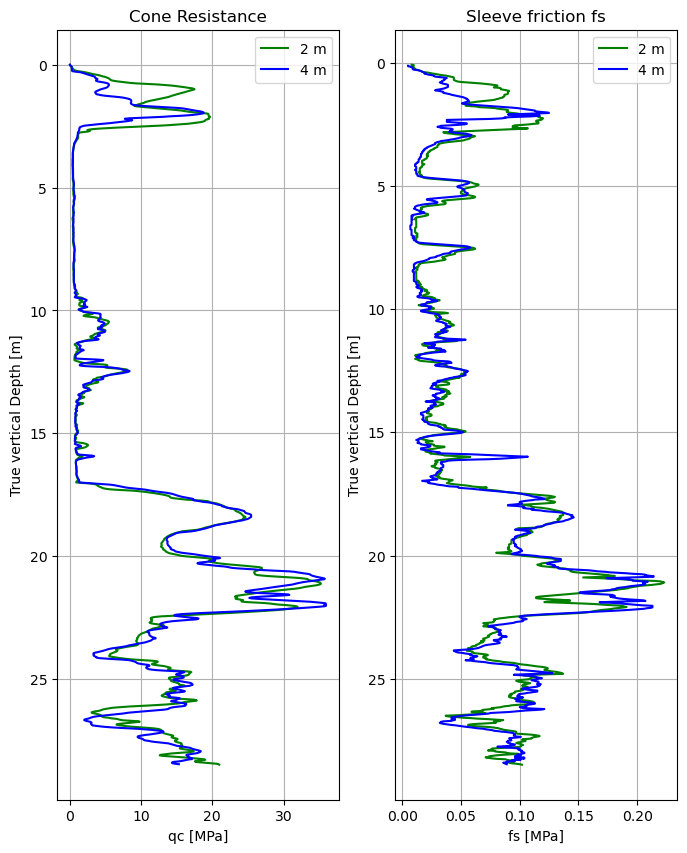

In [3]:
#3 create the plot
plt.figure(figsize=(8, 10))
plt.subplot(1,2,1)

plt.plot(df_2m['qc'], df_2m['corrected depth'], color='green', label='2 m')
plt.plot(df_4m['qc'], df_4m['corrected depth'], color='blue', label='4 m')

plt.xlabel('qc [MPa]')
plt.ylabel('True vertical Depth [m]')
plt.title('Cone Resistance')
plt.legend()
plt.grid()
plt.gca().invert_yaxis()


plt.subplot(1,2,2)
plt.plot(df_2m['fs'], df_2m['corrected depth'], color='green', label='2 m')
plt.plot(df_4m['fs'], df_4m['corrected depth'], color='blue', label='4 m')
plt.xlabel('fs [MPa]')
plt.ylabel('True vertical Depth [m]')
plt.title('Sleeve friction fs')
plt.legend()
plt.grid()
plt.gca().invert_yaxis()

# plt.savefig(r"C:\Users\caupi\OneDrive - Delft University of Technology\Thesis\Python_plots\Midterm\cpt_comparisons_before.png", dpi=300, bbox_inches='tight')

In [4]:
# loading the CPT data after drilling

# depth [m]
# qc [MPa]
# fs [MPa]
# Rf [%]
# u2 [MPa]


# Path to your file (keep it as .gef!)
path_2ma = r"C:\Users\Arend-Jan\CPT measurements\Campus-Zuid\After-boren\S1022749_CPTU2-2.txt"
path_4ma = r"C:\Users\Arend-Jan\CPT measurements\Campus-Zuid\After-boren\S1022749_CPTU2-4.txt"

# 1. Find where the data starts and change all values less than zero to NaN
def load_cpt(path, z_target=-30.0):
    columns = [
        'depth', 'qc', 'fs', 'Rf', 'u2',
        'Slope X', 'Slope Y', 'corrected depth', 'time'
    ]

    a_value = None
    z_start_NAP = None

    with open(path, 'r') as f:
        lines = f.readlines()
        skip_count = 0

        for i, line in enumerate(lines):

            # Area ratio for qt correction
            if '#MEASUREMENTVAR= 3' in line:
                try:
                    a_value = float(line.split(',')[1].strip())
                except (ValueError, IndexError):
                    print(f"Warning: Could not parse area ratio in {path}. Using default.")
                    a_value = 0.8

            # Starting elevation in NAP
            if '#ZID=' in line:
                try:
                    # Example: #ZID= 31000, -1.37, 0.03
                    z_start_NAP = float(line.split(',')[1].strip())
                except (ValueError, IndexError):
                    raise ValueError(f"Could not parse #ZID elevation in {path}")

            # End of header
            if '#EOH=' in line:
                skip_count = i + 1
                break

    if a_value is None:
        raise ValueError(f"Could not find area ratio '#MEASUREMENTVAR= 3' in {path}")

    if z_start_NAP is None:
        raise ValueError(f"Could not find starting elevation '#ZID=' in {path}")

    df = pd.read_csv(path, skiprows=skip_count, sep=r'\s+', header=None)
    df.columns = columns

    # Replace invalid GEF values
    df[df < -200] = np.nan

    # Corrected cone resistance
    df['qt'] = df['qc'] + (df['u2'] * (1 - a_value))

    # Elevation relative to NAP
    df['z_NAP'] = z_start_NAP - df['depth']

    # Keep data down to -30 m NAP
    df = df[df['z_NAP'] >= z_target].copy()

    return df

# 2. Load the dataframes
df_2m_a = load_cpt(path_2ma)
df_4m_a = load_cpt(path_4ma)

df_2m_a.head()

# df_2m_a.to_csv(r"C:\AA_Thesis\CPT_Measurements\Campus-Zuid\After-boren\2m_after.csv", index=False)
# df_4m_a.to_csv(r"C:\AA_Thesis\CPT_Measurements\Campus-Zuid\After-boren\4m_after.csv", index=False)


,depth,qc,fs,Rf,u2,Slope X,Slope Y,corrected depth,time,qt,z_NAP
0,0.00,0.087,NaN,NaN,NaN,-0.945,-1.636,0.00,258.5,NaN,-1.37
1,0.02,0.262,NaN,NaN,-0.001,-0.925,-1.674,0.02,259.3,0.263,-1.39
2,0.04,0.324,NaN,NaN,-0.001,-0.928,-1.645,0.04,260.2,0.325,-1.41
3,0.06,0.360,NaN,NaN,-0.001,-0.955,-1.642,0.06,261.0,0.361,-1.43
4,0.08,0.382,NaN,NaN,-0.001,-0.963,-1.626,0.08,261.8,0.383,-1.45


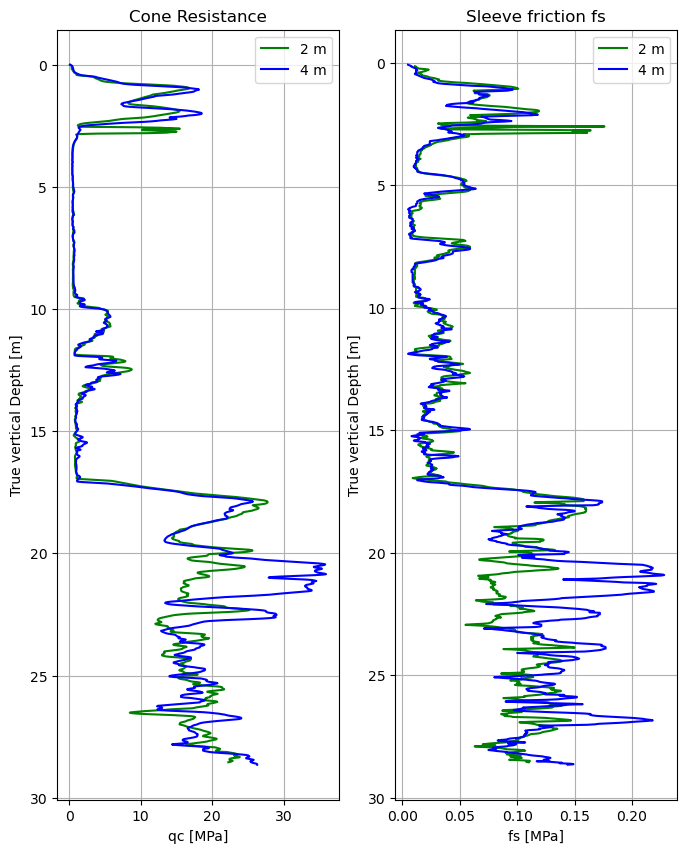

In [5]:
#3 create the plot
plt.figure(figsize=(8, 10))
plt.subplot(1,2,1)

plt.plot(df_2m_a['qc'], df_2m_a['corrected depth'], color='green', label='2 m')
plt.plot(df_4m_a['qc'], df_4m_a['corrected depth'], color='blue', label='4 m')

plt.xlabel('qc [MPa]')
plt.ylabel('True vertical Depth [m]')
plt.title('Cone Resistance')
plt.legend()
plt.grid()
plt.gca().invert_yaxis()


plt.subplot(1,2,2)
plt.plot(df_2m_a['fs'], df_2m_a['corrected depth'], color='green', label='2 m')
plt.plot(df_4m_a['fs'], df_4m_a['corrected depth'], color='blue', label='4 m')
plt.xlabel('fs [MPa]')
plt.ylabel('True vertical Depth [m]')
plt.title('Sleeve friction fs')
plt.legend()
plt.grid()
plt.gca().invert_yaxis()

CPT Data Before and After Drilling


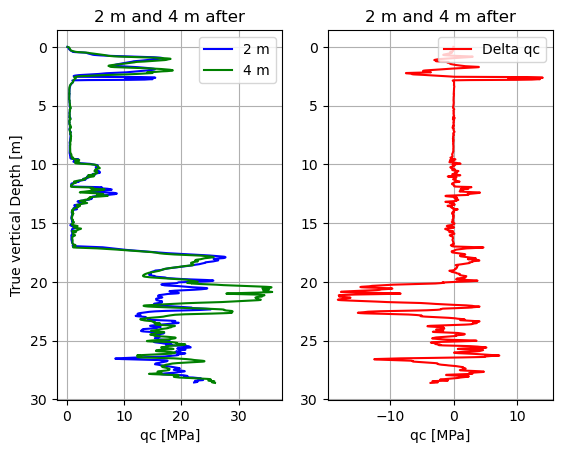

In [6]:
# plot before and after together
def trim_to_shortest(df1, df2):
    n = min(len(df1), len(df2))
    return df1.iloc[:n].copy(), df2.iloc[:n].copy()

df_2m_trim, df_2m_a_trim = trim_to_shortest(df_2m, df_2m_a)
df_2m_a_trim, df_4m_a_trim = trim_to_shortest(df_2m_a, df_4m_a)

print('CPT Data Before and After Drilling')
# plt.figure(figsize=(8, 10))
plt.subplot(1,2,1)
plt.plot(df_2m_a_trim['qc'], df_2m_a_trim['corrected depth'], label='2 m', color='blue')
plt.plot(df_4m_a_trim['qc'], df_4m_a_trim['corrected depth'], label='4 m', color='green')
plt.legend(loc='upper right')
plt.title('2 m and 4 m after')
plt.xlabel('qc [MPa]')
plt.ylabel('True vertical Depth [m]')
plt.gca().invert_yaxis()
plt.grid()

plt.subplot(1,2,2)
delta2_qc = df_2m_a_trim['qc'] - df_4m_a_trim['qc']
plt.plot(delta2_qc, df_4m_a_trim['corrected depth'], label='Delta qc', color='red')
plt.legend(loc='upper right')
plt.title('2 m and 4 m after')
plt.xlabel('qc [MPa]')
plt.gca().invert_yaxis()
plt.grid()

# plt.savefig(r"C:\Users\caupi\OneDrive - Delft University of Technology\Thesis\Python_plots\Midterm\cpt_comparisons_before_after .png", dpi=300, bbox_inches='tight')


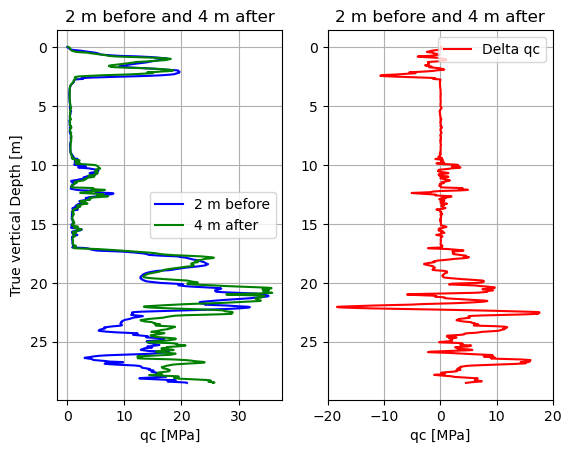

In [7]:
# measurement 2 m before and 2 m after away from borehole
df_2m_trim, df_4m_a_trim = trim_to_shortest(df_2m, df_4m_a)
# df_2m_a_trim, df_2m_a_trim = trim_to_shortest(df_2m_a, df_2m_a)

plt.subplot(1,2,1)
plt.plot(df_2m_trim['qc'], df_2m_trim['corrected depth'], label='2 m before', color='blue')
plt.plot(df_4m_a_trim['qc'], df_4m_a_trim['corrected depth'], label='4 m after', color='green')
plt.legend()
plt.title('2 m before and 4 m after')
plt.xlabel('qc [MPa]')
plt.ylabel('True vertical Depth [m]')
plt.gca().invert_yaxis()
plt.grid()

plt.subplot(1,2,2)
delta2_qc = df_4m_a_trim['qc'] - df_2m_trim['qc']
plt.plot(delta2_qc, df_2m_trim['corrected depth'], label='Delta qc', color='red')
plt.legend(loc='upper right')
plt.title('2 m before and 4 m after')
plt.xlabel('qc [MPa]')
plt.xlim(-20, 20)
plt.gca().invert_yaxis()
plt.grid()

sleeve friction before and after drilling


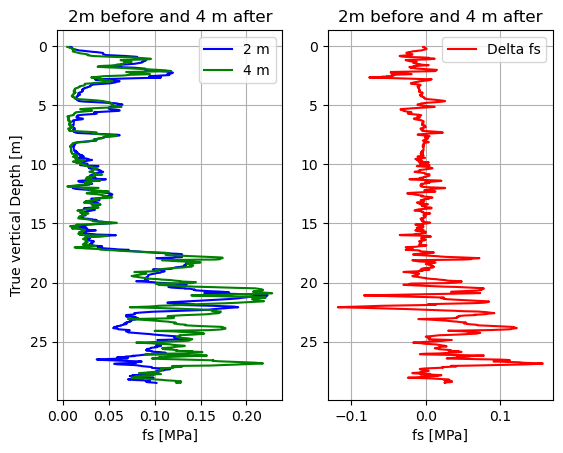

In [8]:
print("sleeve friction before and after drilling")
df_2m_trim, df_2m_a_trim = trim_to_shortest(df_2m, df_2m_a)
df_2m_trim, df_4m_a_trim = trim_to_shortest(df_2m, df_4m_a)


# plt.figure(figsize=(8, 10))
plt.subplot(1,2,1)
plt.plot(df_2m_trim['fs'], df_2m_trim['corrected depth'], label='2 m', color='blue')
plt.plot(df_4m_a_trim['fs'], df_4m_a_trim['corrected depth'], label='4 m', color='green')
plt.legend(loc='upper right')
plt.title('2m before and 4 m after')
plt.xlabel('fs [MPa]')
plt.ylabel('True vertical Depth [m]')
plt.gca().invert_yaxis()
plt.grid()

plt.subplot(1,2,2)
delta2_fs = df_4m_a_trim['fs'] - df_2m_trim['fs']
plt.plot(delta2_fs, df_2m_trim['corrected depth'], label='Delta fs', color='red')
plt.legend(loc='upper right')
plt.title('2m before and 4 m after')
plt.xlabel('fs [MPa]')
plt.gca().invert_yaxis()
plt.grid()

# plt.savefig(r"C:\Users\caupi\OneDrive - Delft University of Technology\Thesis\Python_plots\Midterm\cpt_comparisons_before_after_fs.png", dpi=300, bbox_inches='tight')

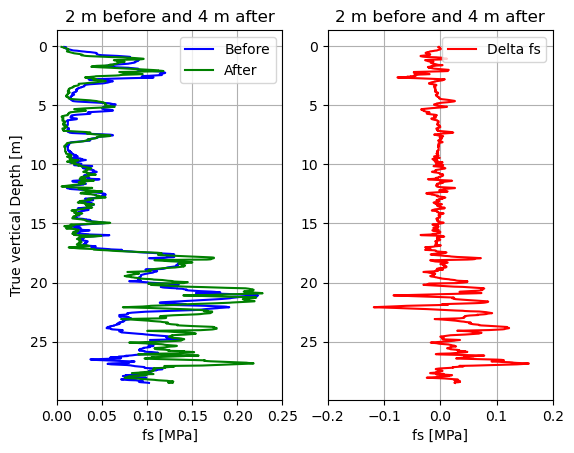

In [9]:
# measurement 4 m away from borehole
df_2m_trim, df_4m_a_trim = trim_to_shortest(df_2m, df_4m_a)
# df_2m_trim, df_2m_a_trim = trim_to_shortest(df_2m, df_2m_a)

plt.subplot(1,2,1)
plt.plot(df_2m_trim['fs'], df_2m_trim['corrected depth'], label='Before', color='blue')
plt.plot(df_4m_a_trim['fs'], df_4m_a_trim['corrected depth'], label='After', color='green')
plt.legend()
plt.title('2 m before and 4 m after')
plt.xlabel('fs [MPa]')
plt.ylabel('True vertical Depth [m]')
plt.xlim(0,0.25)
plt.legend(loc='upper right')
plt.gca().invert_yaxis()
plt.grid()

plt.subplot(1,2,2)
delta4m_a_fs = df_4m_a_trim['fs'] - df_2m_trim['fs']
plt.plot(delta4m_a_fs, df_2m_trim['corrected depth'], label='Delta fs', color='red')
plt.legend(loc='upper right')
plt.title('2 m before and 4 m after')
plt.xlabel('fs [MPa]')
plt.xlim(-0.2, 0.2)
plt.legend(loc='upper right')
plt.gca().invert_yaxis()
plt.grid()

### After Robertson Classification

In [10]:
import pandas as pd
from pathlib import Path

# =============================================================================
# Load classified CPT data
# =============================================================================

m1 = pd.read_csv(r"C:\AA_Thesis\VSCode\lengkeek_vs_code\S1022749_CPTU1-2\classified_points.csv")
m2 = pd.read_csv(r"C:\AA_Thesis\VSCode\lengkeek_vs_code\S1022749_CPTU2-2\classified_points.csv")
m3 = pd.read_csv(r"C:\AA_Thesis\VSCode\lengkeek_vs_code\S1022749_CPTU1-4\classified_points.csv")
m4 = pd.read_csv(r"C:\AA_Thesis\VSCode\lengkeek_vs_code\S1022749_CPTU2-4\classified_points.csv")

# =============================================================================
# Select pile-carrying sand layers per CPT
# =============================================================================

selected_cpts = {
    "CPT1-2": {
        "df": m1,
        # "layers": ["Sand 2", "Sand 3", "Sand 4"],
        "layers": ["Sand 1"],
    },
    "CPT2-2": {
        "df": m2,
        "layers": ["Sand 1"], # sand 4 for bottom layer 
    },
    "CPT1-4": {
        "df": m3,
        # "layers": ["Sand 2", "Sand 3", "Sand 4", "Sand 5"],
        "layers": ["Sand 1"],
    },
    "CPT2-4": {
        "df": m4,
        # "layers": ["Sand 4", "Sand 5", "Sand 6"],
        "layers": ["Sand 1"],
    },
}

# =============================================================================
# Helper functions
# =============================================================================

def selected_layer_series(df, layers, value_col):
    """
    Return the selected value column for the selected layer IDs.
    All selected layers are combined into one series.
    """
    return (
        df.loc[df["layer_id"].isin(layers), value_col]
        .dropna()
        .astype(float)
    )


def make_describe_table(selected_cpts, value_col):
    """
    Create a describe() table with CPTs as columns.
    """
    describe_data = {}

    for cpt_name, info in selected_cpts.items():
        series = selected_layer_series(
            df=info["df"],
            layers=info["layers"],
            value_col=value_col,
        )

        describe_data[cpt_name] = series.describe()

    table = pd.DataFrame(describe_data)

    # Optional: cleaner row order
    row_order = ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
    table = table.loc[row_order]

    return table


# =============================================================================
# Create tables
# =============================================================================

qt_over_pa_table = make_describe_table(selected_cpts, "qt_over_pa")
rf_percent_table = make_describe_table(selected_cpts, "rf_percent")

# Display in notebook
display(qt_over_pa_table)
display(rf_percent_table)

,CPT1-2,CPT2-2,CPT1-4,CPT2-4
count,121.000000,117.000000,92.000000,99.000000
mean,119.767987,98.894802,75.895767,116.948673
std,58.315436,47.903573,59.321012,45.022357
min,11.644000,9.689400,8.642200,35.278800
25%,80.791600,69.029400,13.427100,75.970200
50%,131.198400,107.933200,79.031000,119.012600
75%,166.915800,140.190000,107.217700,157.202100
max,196.870000,167.590000,187.856400,185.224200


,CPT1-2,CPT2-2,CPT1-4,CPT2-4
count,121.000000,117.000000,92.000000,99.000000
mean,1.065744,1.132496,1.781370,0.571495
std,1.083190,1.173251,1.697299,0.254972
min,0.463000,0.253000,0.500000,0.306000
25%,0.528000,0.570000,0.629750,0.399000
50%,0.615000,0.697000,0.736000,0.508000
75%,0.735000,0.903000,2.525500,0.660500
max,5.158000,5.437000,5.731000,1.804000


CPT1-2centre Rf: 2.62%, centre qt/pa: 12.87
CPT2-2centre Rf: 2.42%, centre qt/pa: 11.46
CPT1-4centre Rf: 2.64%, centre qt/pa: 11.47
CPT2-4centre Rf: 1.96%, centre qt/pa: 13.19


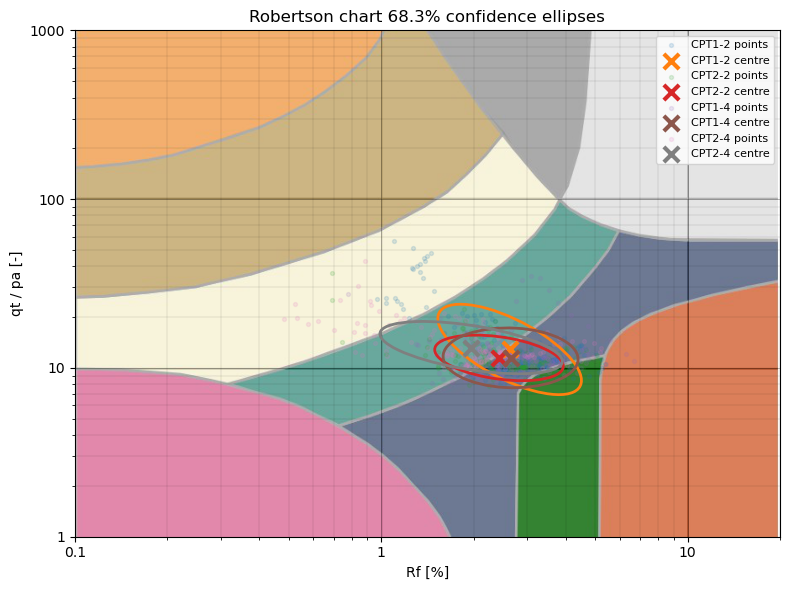

,CPT,n,centre_Rf_percent,centre_qt_over_pa,std_log10_Rf,std_log10_qt_over_pa
0,CPT1-2,199,2.623251,12.867686,0.154163,0.176173
1,CPT2-2,181,2.421860,11.464061,0.137996,0.088817
2,CPT1-4,187,2.642193,11.474405,0.144884,0.116543
3,CPT2-4,178,1.964693,13.192223,0.195837,0.101980


In [20]:
def selected_sand_data(df, layers):
    data = df.loc[
        df["layer_id"].isin(layers),
        ["rf_percent", "qt_over_pa"]
    ].dropna().copy()

    data = data[
        (data["rf_percent"] > 0) &
        (data["qt_over_pa"] > 0)
    ].copy()

    data["log_rf_percent"] = np.log10(data["rf_percent"])
    data["log_qt_over_pa"] = np.log10(data["qt_over_pa"])

    return data


def add_covariance_ellipse(ax, x, y, n_std=1.0, **kwargs):
    if len(x) < 3:
        return

    cov = np.cov(x, y)

    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]

    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    angle = np.degrees(
        np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0])
    )

    width, height = 2 * n_std * np.sqrt(eigenvalues) # times 2 for full width and height of the ellipse

    ellipse = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width,
        height=height,
        angle=angle,
        fill=False,
        linewidth=2,
        **kwargs
    )

    ax.add_patch(ellipse)

confidence = 1.52 # Set your confidence ellipse 1.52=68.3%, 2.45=95.4%, 2.14=90% , 1.0=1 std (39.35%), it is the square root of the chi-squared value for 2 degrees of freedom (Rf and qt/pa) at the desired confidence level

selected_cpts = {
    "CPT1-2": {
        "df": m1,
        "layers": ["Silty clay / clayey silt 2", "Clay & silt 3", "Clay & silt 4"],
        # "layers": ["Peat 2"], # layer just above foundation layer
    },  
    "CPT2-2": {
        "df": m2,
        # "layers": ["Peat 3"], # just above the foundation layer
        "layers": ["Silty clay / clayey silt 2", "Clay & silt 3", "Silty clay / clayey silt 3", "Clay & silt 4", "Silty clay / clayey silt 4",],
    },
    "CPT1-4": {
        "df": m3,
        "layers": ["Silty clay / clayey silt 2", "Clay & silt 4", "Clay & silt 5", "Silty clay / clayey silt 3"],
        # "layers": ["Peat 2"],
    },
    "CPT2-4": {
        "df": m4,
        "layers": ["Silty clay / clayey silt 4", "Silty clay / clayey silt 5", "Silty clay / clayey silt 6",],
        # "layers": ["Peat 2"],
    },
}


background_path = r"C:\AA_Thesis\VSCode\lengkeek_vs_code\lengkeek_chart_clean.jpg"

fig, ax = create_lengkeek_background_axis(
    background_path=background_path,
    figsize=(8, 6),
    alpha=1.0
)

stats_rows = []

for name, info in selected_cpts.items():
    data = selected_sand_data(info["df"], info["layers"])

    if data.empty:
        print(f"Warning: no data for {name}")
        continue

    x = data["log_rf_percent"].values
    y = data["log_qt_over_pa"].values

    ax.scatter(
        x,
        y,
        s=8,
        alpha=0.15,
        label=f"{name} points",
        zorder=2
    )

    x_mean = np.mean(x)
    y_mean = np.mean(y)

    centre = ax.scatter(
        x_mean,
        y_mean,
        s=120,
        marker="x",
        linewidths=3,
        label=f"{name} centre",
        zorder=4
    )

    centre_colour = centre.get_edgecolors()[0]

    add_covariance_ellipse(
        ax,
        x,
        y,
        n_std=confidence,
        edgecolor=centre_colour,
        zorder=3
    )

    stats_rows.append({
        "CPT": name,
        "n": len(data),
        "centre_Rf_percent": 10 ** x_mean,
        "centre_qt_over_pa": 10 ** y_mean,
        "std_log10_Rf": np.std(x, ddof=1),
        "std_log10_qt_over_pa": np.std(y, ddof=1),
    })

    print(
        f"{name}"
        f"centre Rf: {10**x_mean:.2f}%, "
        f"centre qt/pa: {10**y_mean:.2f}"
    )


ax.set_title("Robertson chart 68.3% confidence ellipses")
ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()

stats_df = pd.DataFrame(stats_rows)
display(stats_df)

## Soil parameters following Table 2b in NEN-EN

In [12]:
param1_2 = pd.read_csv(r'C:\AA_Thesis\VSCode\lengkeek_vs_code\S1022749_CPTU1-2\layer_parameters.csv')

param1_2.head(39)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\AA_Thesis\\VSCode\\lengkeek_vs_code\\S1022749_CPTU1-2\\layer_parameters.csv'

### dataframe made smaller up to a depth of -25 NAP so in the case of CPT1-2 Sand layer 3

In [ ]:
df = param1_2.iloc[:28].copy()

same_value_cols = [
    "gamma_unsat_kn_m3",
    "gamma_sat_kn_m3",
    "E100_mpa",
    "c_prime_kpa",
    "phi_prime_deg",
    "dilatancy_deg",
]

same_value_cols = [col for col in same_value_cols if col in df.columns]

group_id = (df[same_value_cols] != df[same_value_cols].shift()).any(axis=1).cumsum()

combined = (
    df.groupby(group_id, as_index=False)
    .agg(
        soil_id=("soil_id", lambda x: " + ".join(x.astype(str))),
        top_elevation_m_nap=("top_elevation_m_nap", "first"),
        qc_mpa_mean=("qc_mpa_mean", "mean"),
        gamma_unsat_kn_m3=("gamma_unsat_kn_m3", "first"),
        gamma_sat_kn_m3=("gamma_sat_kn_m3", "first"),
        E100_mpa=("E100_mpa", "first"),
        c_prime_kpa=("c_prime_kpa", "first"),
        phi_prime_deg=("phi_prime_deg", "first"),
        dilatancy_deg=("dilatancy_deg", "first"),
        interpolation_status=("interpolation_status", "first"),
    )
)

combined

C:\Users\caupi\AppData\Local\Temp\ipykernel_20340\2855455988.py:17: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This grouping will be included in a future version of pandas. Add the grouping as a column of the DataFrame to silence this warning.
  df.groupby(group_id, as_index=False)


,soil_id,top_elevation_m_nap,qc_mpa_mean,gamma_unsat_kn_m3,gamma_sat_kn_m3,E100_mpa,c_prime_kpa,phi_prime_deg,dilatancy_deg,interpolation_status
0,Organic clay 1,-1.56,0.460,15.1,15.1,1.35,0.50,15.0,0.0,interpolated
1,Sand mixtures 1,-1.74,3.490,18.5,20.5,22.50,0.00,27.5,0.0,below_range_clipped
2,Sand 1,-2.04,13.760,17.9,19.9,41.28,0.00,32.2,2.2,interpolated
3,Silty clay / clayey silt 1,-4.10,1.770,19.8,19.8,2.77,0.77,29.7,0.0,interpolated
4,Peat 1,-4.46,0.590,12.5,12.5,0.75,3.75,15.0,0.0,above_range_clipped
5,Organic clay 2,-5.40,0.400,14.7,14.7,1.16,0.50,15.0,0.0,interpolated
6,Peat 2,-6.16,0.540,12.5,12.5,0.75,3.75,15.0,0.0,above_range_clipped
7,Organic clay 3,-7.26,0.470,15.2,15.2,1.38,0.50,15.0,0.0,interpolated
8,Clay & silt 1 + Clay & silt 2 + Clay & silt 3,-7.78,0.460,15.0,15.0,1.50,0.00,22.5,0.0,below_range_clipped
9,Peat 3,-8.88,0.630,12.5,12.5,0.75,3.75,15.0,0.0,above_range_clipped
